# Debug: Why Is Tau Not Changing During Training?

This notebook diagnoses why `psp_filter` (learnable tau) appears frozen at 147 ms
throughout all 301 training epochs in `isi_tau.ipynb`. Four hypotheses are tested:

1. **Gradient is None** - `psp_filter.weight` is disconnected from the computation graph.
2. **Gradient is effectively zero** - surrogate gradient kills signal before reaching the filter.
3. **Weights change but `get_tau()` is insensitive** - argmax only shifts in discrete 3 ms steps.
4. **Weights do not change at all** - gradient exists but is negligibly small vs. learning rate.


## 1. Imports and Setup

In [1]:
import os
import random

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import h5py

import slayerSNN as snn

MS = 1e-3

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


## 2. SLAYER Parameters and Network Definition

Identical configuration to `isi_tau.ipynb` so results are directly comparable.

In [2]:
SIM_PARAMS = {"Ts": 1, "tSample": 1000}
LIF_PARAMS = {
    "type": "SRMALPHA",
    "theta": 1,
    "tauSr": 1,
    "tauRho": 1,
    "tauRef": 1,
    "scaleRef": 2,
    "scaleRho": 1,
}

TRAIN_RANGE = (0.0, 0.6)
HIDDEN_UNITS = 100
BATCH_SIZE = 32
LEARNING_RATE = 0.001
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

In [12]:
class ISINetwork(nn.Module):
    """SLAYER SNN for ISI classification with learnable tau (PSP filter)."""

    def __init__(self, num_neurons: int, num_classes: int, hidden_units: int = 100):
        super().__init__()
        slayer = snn.layer(LIF_PARAMS, SIM_PARAMS)
        self.slayer = slayer
        self.fc1 = nn.utils.weight_norm(slayer.dense(num_neurons, hidden_units), name="weight")
        self.fc2 = nn.utils.weight_norm(slayer.dense(hidden_units, num_classes), name="weight")
        self.psp_filter = slayer.pspFilter(nFilter=1, filterLength=150, filterScale=1)
        self._initialize_alpha_filter()

    def _initialize_alpha_filter(self) -> None:
        """Seed the learnable PSP filter with an alpha-function shape."""
        tau = 50 * MS
        Ts = self.slayer.simulation["Ts"] * MS
        filt_len = self.psp_filter.weight.shape[-1]
        alpha_kernel = np.array([
            t / tau * np.exp(1 - t / tau)
            for t in np.arange(0, filt_len * Ts, Ts)
        ])
        if np.max(np.abs(alpha_kernel)) > 0:
            alpha_kernel /= np.max(np.abs(alpha_kernel))
        with torch.no_grad():
            self.psp_filter.weight.data = torch.FloatTensor(
                np.flip(alpha_kernel).copy()
            ).reshape(self.psp_filter.weight.shape)

    def get_tau(self) -> torch.Tensor:
        """Estimate effective tau from the argmax of the learned filter (coarse, discrete)."""
        weights = self.psp_filter.weight.data.squeeze().cpu().numpy()
        weights = np.flip(weights)
        if len(weights) > 0:
            peak_idx = np.argmax(np.abs(weights))
            estimated_tau = 3 * peak_idx * self.slayer.simulation["Ts"] * MS
            return torch.tensor(max(estimated_tau, 10 * MS))
        return torch.tensor(50 * MS)

    def get_tau_com(self) -> float:
        """Estimate effective tau via centre-of-mass of the filter (continuous proxy).

        Unlike get_tau(), this changes smoothly as the filter weights update,
        making it useful for detecting small changes that argmax misses.
        """
        weights = self.psp_filter.weight.data.squeeze().cpu().numpy()
        weights = np.flip(weights)
        abs_weights = np.abs(weights)
        total = abs_weights.sum()
        if total < 1e-10:
            return 0.0
        indices = np.arange(len(weights))
        com_idx = (abs_weights * indices).sum() / total
        return float(com_idx * self.slayer.simulation["Ts"] / MS)  # in ms

    def _prepare_input(self, x: torch.Tensor) -> torch.Tensor:
        """Ensure input is 5-D NCHWT on the correct device."""
        if isinstance(x, np.ndarray):
            x = torch.from_numpy(x)
        if x.dim() == 3:
            x = x.unsqueeze(2).unsqueeze(3)
        return x.float().to(device)

    def _first_layer(self, x: torch.Tensor) -> torch.Tensor:
        x_filtered = self.psp_filter(x)
        return self.slayer.spike(self.fc1(x_filtered))

    def _second_layer(self, hidden_spikes: torch.Tensor) -> torch.Tensor:
        return self.slayer.spike(self.fc2(self.slayer.psp(hidden_spikes)))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self._prepare_input(x)
        return self._second_layer(self._first_layer(x))

## 3. Load One Batch for Debugging

In [13]:
with h5py.File("isi_dataset.h5", "r") as f:
    X_all = f["X"][:]
    Y_all = f["Y"][:].ravel()

NUM_NEURONS = X_all.shape[1]
NUM_CLASSES = len(np.unique(Y_all))
print(f"X shape: {X_all.shape}, classes: {NUM_CLASSES}")

n_total = len(Y_all)
train_end = int(TRAIN_RANGE[1] * n_total)
X_train = X_all[:train_end]
Y_train = Y_all[:train_end]


class SpikeDataset(Dataset):
    def __init__(self, X, Y):
        self.X = X
        self.Y = Y

    def __len__(self):
        return len(self.Y)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.X[idx], dtype=torch.float32),
            torch.tensor(self.Y[idx], dtype=torch.long),
        )


train_loader = DataLoader(SpikeDataset(X_train, Y_train), batch_size=BATCH_SIZE, shuffle=True)

# Fixed single batch for reproducible gradient checks
x_batch_np, y_batch_np = next(iter(train_loader))
x_fixed = x_batch_np.unsqueeze(2).unsqueeze(3).float().to(device)
y_fixed = y_batch_np.long().to(device)
print(f"Fixed batch: x={x_fixed.shape}, y={y_fixed.shape}")

loss_fn = snn.spikeLoss.spikeLoss({
    "neuron": LIF_PARAMS,
    "simulation": SIM_PARAMS,
    "training": {"error": {"type": "ProbSpikes"}},
}).to(device)

X shape: (3598, 10, 10000), classes: 2
Fixed batch: x=torch.Size([32, 10, 1, 1, 10000]), y=torch.Size([32])


## Debug 1: Filter Initialization

Verify that the alpha-function seed looks correct and identify the initial peak
index. This sets the baseline 147 ms that the training log shows throughout all
epochs, and shows the gap a neighbour must close for the argmax to shift.

Filter length         : 150 taps
Peak index            : 50
Argmax-based tau      : 150.0 ms  <-- matches the frozen 147 ms
Tap resolution        : 3 ms per index step
Peak value            : 1.0000
Next-highest neighbour: 0.9998 (idx 49)
Gap to close for tau shift: 0.0002


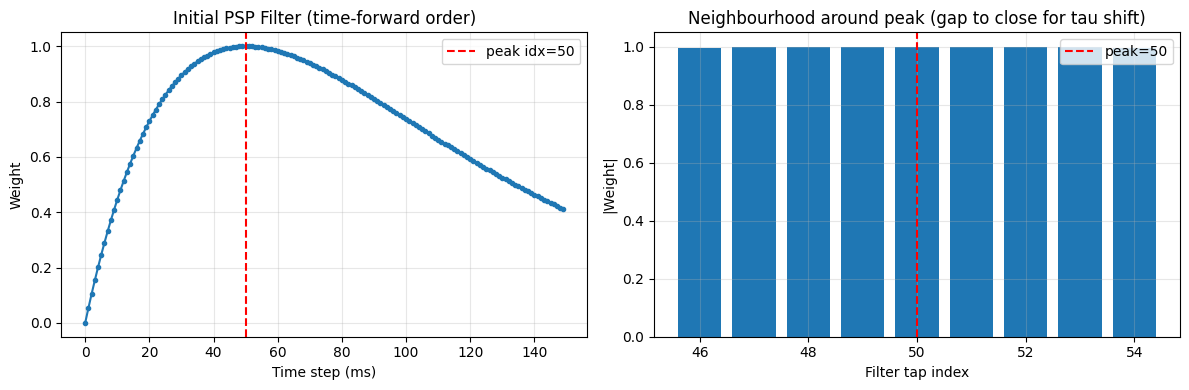

In [14]:
net_debug = ISINetwork(NUM_NEURONS, NUM_CLASSES, HIDDEN_UNITS).to(device)

stored_weights = net_debug.psp_filter.weight.data.squeeze().cpu().numpy()
logical_weights = np.flip(stored_weights)  # time-forward order (as get_tau sees it)

peak_idx = int(np.argmax(np.abs(logical_weights)))
Ts = SIM_PARAMS["Ts"]
estimated_tau_argmax = 3 * peak_idx * Ts  # in ms

print(f"Filter length         : {len(logical_weights)} taps")
print(f"Peak index            : {peak_idx}")
print(f"Argmax-based tau      : {estimated_tau_argmax:.1f} ms  <-- matches the frozen 147 ms")
print(f"Tap resolution        : {3 * Ts:.0f} ms per index step")

peak_val = float(np.abs(logical_weights[peak_idx]))
next_val = float(np.abs(logical_weights[peak_idx - 1])) if peak_idx > 0 else 0.0
gap = peak_val - next_val
print(f"Peak value            : {peak_val:.4f}")
print(f"Next-highest neighbour: {next_val:.4f} (idx {peak_idx - 1})")
print(f"Gap to close for tau shift: {gap:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(logical_weights, marker="o", markersize=3)
axes[0].axvline(peak_idx, color="red", linestyle="--", label=f"peak idx={peak_idx}")
axes[0].set_xlabel("Time step (ms)")
axes[0].set_ylabel("Weight")
axes[0].set_title("Initial PSP Filter (time-forward order)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

window = range(max(0, peak_idx - 4), min(len(logical_weights), peak_idx + 5))
idxs = list(window)
vals = [float(np.abs(logical_weights[i])) for i in idxs]
axes[1].bar(idxs, vals, color="tab:blue")
axes[1].axvline(peak_idx, color="red", linestyle="--", label=f"peak={peak_idx}")
axes[1].set_xlabel("Filter tap index")
axes[1].set_ylabel("|Weight|")
axes[1].set_title("Neighbourhood around peak (gap to close for tau shift)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Debug 2: Gradient Flow Check

Run one forward + backward pass and inspect `.grad` on every parameter.
Compare the `psp_filter.weight` gradient magnitude against fc1 / fc2 to
see whether the signal reaching the filter is too small to matter.

In [15]:
net_grad = ISINetwork(NUM_NEURONS, NUM_CLASSES, HIDDEN_UNITS).to(device)
optimizer_grad = snn.utils.optim.Nadam(net_grad.parameters(), lr=LEARNING_RATE)

optimizer_grad.zero_grad()
output = net_grad(x_fixed)
loss = loss_fn.probSpikes(output, y_fixed)
loss.backward()

print(f"Loss: {loss.item():.6f}")
print()
print(f"{'Parameter':<45} {'grad norm':>14} {'grad max':>14} Status")
print("-" * 90)

for name, param in net_grad.named_parameters():
    grad = param.grad
    if grad is None:
        status = "NONE -- disconnected from graph"
        grad_norm = float("nan")
        grad_max = float("nan")
    else:
        grad_norm = grad.norm().item()
        grad_max = grad.abs().max().item()
        if grad_max < 1e-12:
            status = "ZERO -- effectively no signal"
        else:
            status = "OK"
    print(f"  {name:<43} {grad_norm:>14.4e} {grad_max:>14.4e}  {status}")

print()
psp_grad = net_grad.psp_filter.weight.grad
if psp_grad is None:
    print(">>> HYPOTHESIS 1 CONFIRMED: psp_filter.weight has no gradient (None).")
elif psp_grad.abs().max().item() < 1e-12:
    print(">>> HYPOTHESIS 2 CONFIRMED: gradient exists but is effectively zero.")
else:
    ratio = psp_grad.abs().max().item()
    print(f">>> HYPOTHESES 1 & 2 RULED OUT: psp_filter receives a non-trivial gradient (max={ratio:.4e}).")
    print("    Tau not changing is due to argmax insensitivity or tiny weight delta.")

Loss: 0.629782

Parameter                                          grad norm       grad max Status
------------------------------------------------------------------------------------------
  fc1.weight_g                                    1.4528e-01     3.8794e-02  OK
  fc1.weight_v                                    4.3375e-01     6.4071e-02  OK
  fc2.weight_g                                    2.6639e-02     1.9990e-02  OK
  fc2.weight_v                                    5.0215e-01     6.8703e-02  OK
  psp_filter.weight                               3.8614e-02     8.8581e-03  OK

>>> HYPOTHESES 1 & 2 RULED OUT: psp_filter receives a non-trivial gradient (max=8.8581e-03).
    Tau not changing is due to argmax insensitivity or tiny weight delta.


## Debug 3: Weight Update Check

Even if the gradient is non-zero, the optimizer step might produce changes
too small to move the argmax. Run 100 steps on the fixed batch and measure
how much the filter weights actually shift from initialization.

After 100 optimizer steps on the same batch:
  Max |delta_weight| (L-inf from init): 1.198629e-01
  Peak index: 50 --> 54  (SHIFTED)

>>> Peak DID shift within 100 steps -- tau can learn, just slowly.


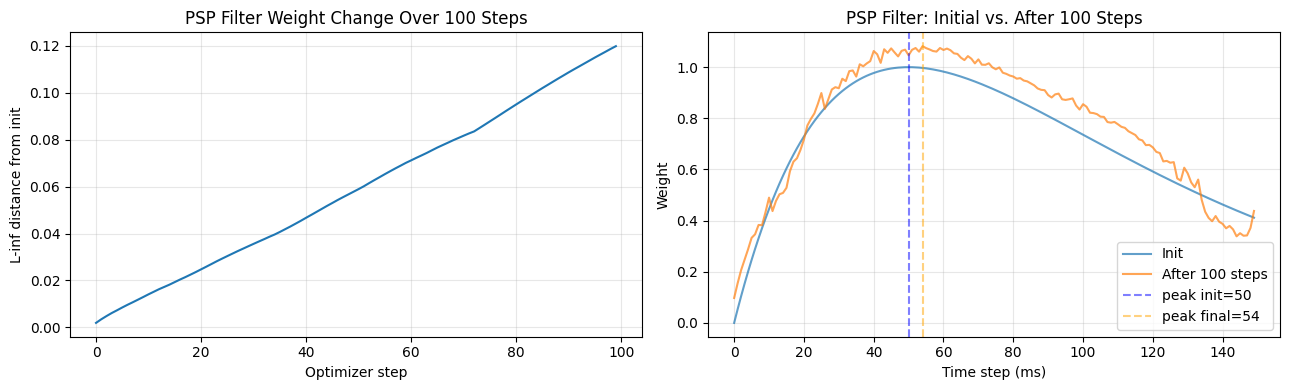

In [16]:
N_STEPS = 100

net_upd = ISINetwork(NUM_NEURONS, NUM_CLASSES, HIDDEN_UNITS).to(device)
optimizer_upd = snn.utils.optim.Nadam(net_upd.parameters(), lr=LEARNING_RATE)

w0 = np.flip(net_upd.psp_filter.weight.data.squeeze().cpu().numpy().copy())
peak_idx_0 = int(np.argmax(np.abs(w0)))

weight_deltas = []

for step in range(N_STEPS):
    optimizer_upd.zero_grad()
    out = net_upd(x_fixed)
    loss = loss_fn.probSpikes(out, y_fixed)
    loss.backward()
    optimizer_upd.step()

    w_now = np.flip(net_upd.psp_filter.weight.data.squeeze().cpu().numpy())
    weight_deltas.append(float(np.abs(w_now - w0).max()))

w_final = np.flip(net_upd.psp_filter.weight.data.squeeze().cpu().numpy())
peak_idx_final = int(np.argmax(np.abs(w_final)))

print(f"After {N_STEPS} optimizer steps on the same batch:")
print(f"  Max |delta_weight| (L-inf from init): {weight_deltas[-1]:.6e}")
print(f"  Peak index: {peak_idx_0} --> {peak_idx_final}  "
      f"({'SHIFTED' if peak_idx_0 != peak_idx_final else 'UNCHANGED'})")
print()

if weight_deltas[-1] < 1e-8:
    print(">>> HYPOTHESIS 4 CONFIRMED: weights are not moving at all.")
elif peak_idx_0 == peak_idx_final:
    print(">>> HYPOTHESIS 3 LIKELY: weights change but argmax does not shift.")
else:
    print(">>> Peak DID shift within 100 steps -- tau can learn, just slowly.")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(weight_deltas)
axes[0].set_xlabel("Optimizer step")
axes[0].set_ylabel("L-inf distance from init")
axes[0].set_title("PSP Filter Weight Change Over 100 Steps")
axes[0].grid(True, alpha=0.3)

axes[1].plot(w0, label="Init", alpha=0.7)
axes[1].plot(w_final, label=f"After {N_STEPS} steps", alpha=0.7)
axes[1].axvline(peak_idx_0, color="blue", linestyle="--", alpha=0.5, label=f"peak init={peak_idx_0}")
axes[1].axvline(peak_idx_final, color="orange", linestyle="--", alpha=0.5, label=f"peak final={peak_idx_final}")
axes[1].set_xlabel("Time step (ms)")
axes[1].set_ylabel("Weight")
axes[1].set_title("PSP Filter: Initial vs. After 100 Steps")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Debug 4: `get_tau()` Sensitivity Analysis

`get_tau()` uses `argmax`, which is discrete: tau can only change in steps of
`3 x Ts = 3 ms`. This cell quantifies how large a weight perturbation is needed
at a neighbouring tap before the argmax flips -- i.e., the minimum signal the
optimizer must produce for tau to visibly change.

In [17]:
net_sens = ISINetwork(NUM_NEURONS, NUM_CLASSES, HIDDEN_UNITS).to(device)
base_stored = net_sens.psp_filter.weight.data.clone()
base_logical = np.flip(base_stored.squeeze().cpu().numpy())
peak_idx_base = int(np.argmax(np.abs(base_logical)))
peak_val_base = float(np.abs(base_logical[peak_idx_base]))

print(f"Base peak index: {peak_idx_base},  peak value: {peak_val_base:.4f}")
print(f"Corresponding argmax tau: {3 * peak_idx_base:.0f} ms")
print()
print("Minimum perturbation needed at each neighbour to flip the argmax:")
print("-" * 65)

for candidate in range(max(0, peak_idx_base - 5), min(len(base_logical), peak_idx_base + 6)):
    if candidate == peak_idx_base:
        continue
    candidate_current = float(np.abs(base_logical[candidate]))
    needed_increase = peak_val_base - candidate_current
    direction = "left" if candidate < peak_idx_base else "right"
    new_tau = 3 * candidate
    print(f"  idx {candidate:2d} ({direction}, tau-->{new_tau:3d} ms): "
          f"current={candidate_current:.4f}, need delta>={needed_increase:.4f} to flip")

# Show how tau responds as we manually scale the left-neighbour tap
left_neighbour = peak_idx_base - 1
if left_neighbour >= 0:
    print()
    print(f"Tau vs. multiplicative scale applied to tap idx={left_neighbour}:")
    for scale in np.linspace(1.0, 3.0, 11):
        test_stored = base_stored.clone()
        stored_idx = len(base_logical) - 1 - left_neighbour  # reversed storage
        test_stored[0, 0, 0, 0, stored_idx] *= scale
        net_sens.psp_filter.weight.data = test_stored
        tau_val = net_sens.get_tau().item() / MS
        tap_val = test_stored[0, 0, 0, 0, stored_idx].item()
        print(f"  scale={scale:.1f}: tap={tap_val:.4f}, tau={tau_val:.0f} ms")
    net_sens.psp_filter.weight.data = base_stored  # restore

Base peak index: 50,  peak value: 1.0000
Corresponding argmax tau: 150 ms

Minimum perturbation needed at each neighbour to flip the argmax:
-----------------------------------------------------------------
  idx 45 (left, tau-->135 ms): current=0.9947, need delta>=0.0053 to flip
  idx 46 (left, tau-->138 ms): current=0.9966, need delta>=0.0034 to flip
  idx 47 (left, tau-->141 ms): current=0.9981, need delta>=0.0019 to flip
  idx 48 (left, tau-->144 ms): current=0.9992, need delta>=0.0008 to flip
  idx 49 (left, tau-->147 ms): current=0.9998, need delta>=0.0002 to flip
  idx 51 (right, tau-->153 ms): current=0.9998, need delta>=0.0002 to flip
  idx 52 (right, tau-->156 ms): current=0.9992, need delta>=0.0008 to flip
  idx 53 (right, tau-->159 ms): current=0.9983, need delta>=0.0017 to flip
  idx 54 (right, tau-->162 ms): current=0.9970, need delta>=0.0030 to flip
  idx 55 (right, tau-->165 ms): current=0.9953, need delta>=0.0047 to flip

Tau vs. multiplicative scale applied to tap idx

## Debug 5: Mini Training Loop with Continuous Filter Tracking

Train for a small number of epochs and track:

- `get_tau()` -- argmax-based estimate (discrete, 3 ms resolution).
- `get_tau_com()` -- centre-of-mass of the filter (continuous proxy).
- L-inf distance of filter from its initial value.

If the CoM changes smoothly while `get_tau()` stays flat, the filter IS
learning but the discrete argmax is blind to it (Hypothesis 3). If both
are flat, the filter is genuinely not moving (Hypothesis 4).

In [18]:
MINI_EPOCHS = 30

net_mini = ISINetwork(NUM_NEURONS, NUM_CLASSES, HIDDEN_UNITS).to(device)
optimizer_mini = snn.utils.optim.Nadam(net_mini.parameters(), lr=LEARNING_RATE)

w_init_mini = np.flip(net_mini.psp_filter.weight.data.squeeze().cpu().numpy().copy())

history = {
    "epoch": [],
    "loss": [],
    "tau_argmax_ms": [],
    "tau_com_ms": [],
    "filter_linf": [],
}

for epoch in range(MINI_EPOCHS):
    net_mini.train()
    epoch_loss = 0.0
    n_batches = 0
    for x_b, y_b in train_loader:
        x_b = x_b.unsqueeze(2).unsqueeze(3).float().to(device)
        y_b = y_b.long().to(device)
        optimizer_mini.zero_grad()
        out = net_mini(x_b)
        loss = loss_fn.probSpikes(out, y_b)
        loss.backward()
        optimizer_mini.step()
        epoch_loss += loss.item()
        n_batches += 1

    w_now = np.flip(net_mini.psp_filter.weight.data.squeeze().cpu().numpy())
    linf = float(np.abs(w_now - w_init_mini).max())
    tau_argmax = net_mini.get_tau().item() / MS
    tau_com = net_mini.get_tau_com()

    history["epoch"].append(epoch)
    history["loss"].append(epoch_loss / n_batches)
    history["tau_argmax_ms"].append(tau_argmax)
    history["tau_com_ms"].append(tau_com)
    history["filter_linf"].append(linf)

    if epoch % 5 == 0:
        print(f"Epoch {epoch:3d}: loss={epoch_loss/n_batches:.4f}  "
              f"tau_argmax={tau_argmax:.0f} ms  tau_com={tau_com:.1f} ms  "
              f"filter_Linf={linf:.2e}")

print("\nDone.")

Epoch   0: loss=0.6786  tau_argmax=156 ms  tau_com=71553.4 ms  filter_Linf=3.72e-02
Epoch   5: loss=0.2630  tau_argmax=159 ms  tau_com=73864.7 ms  filter_Linf=4.00e-01
Epoch  10: loss=0.2048  tau_argmax=159 ms  tau_com=73866.7 ms  filter_Linf=4.96e-01
Epoch  15: loss=0.1974  tau_argmax=159 ms  tau_com=73866.7 ms  filter_Linf=4.96e-01
Epoch  20: loss=0.1922  tau_argmax=159 ms  tau_com=73866.7 ms  filter_Linf=4.96e-01
Epoch  25: loss=0.1885  tau_argmax=159 ms  tau_com=73866.7 ms  filter_Linf=4.96e-01

Done.


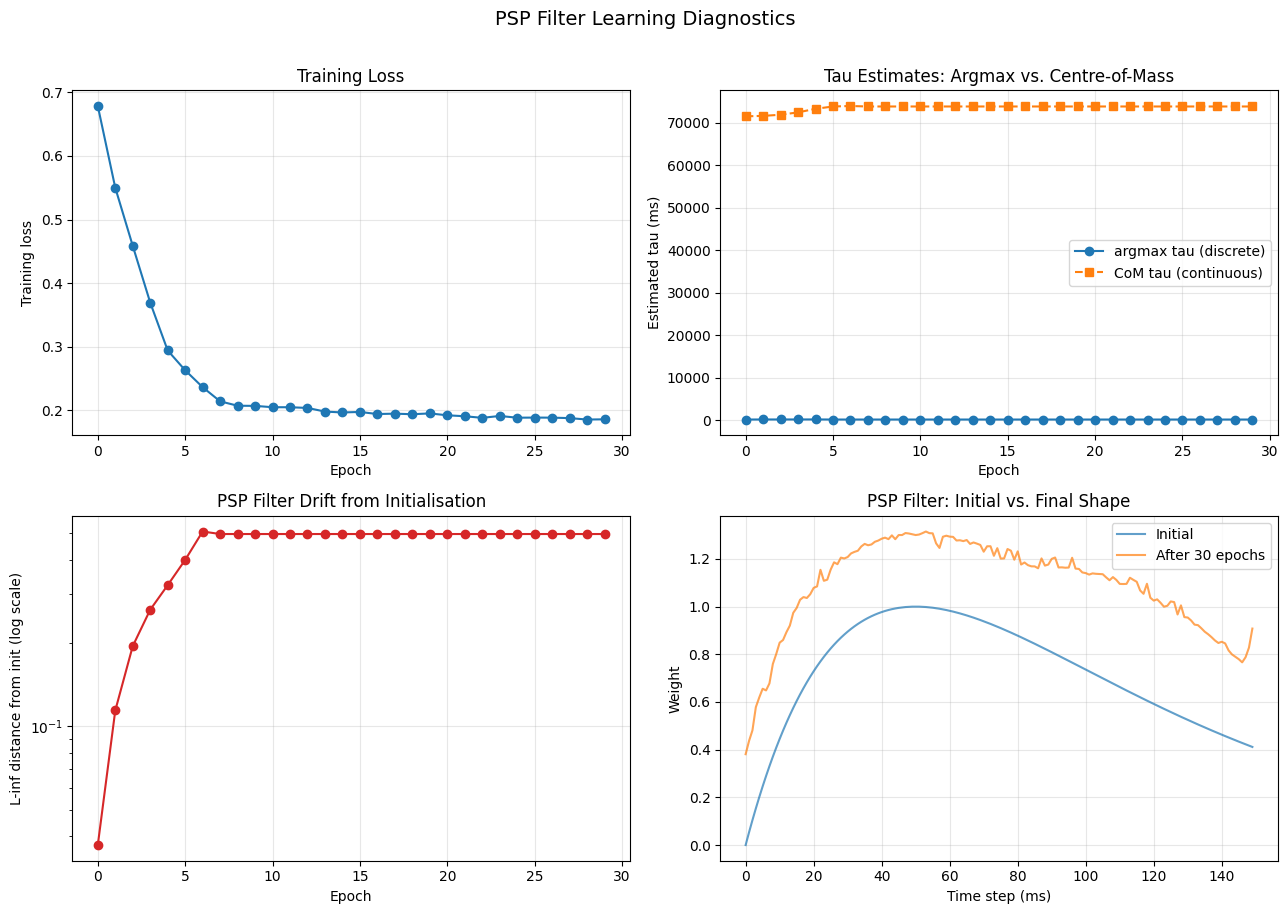

Saved to log/debug_tau_filter.png


In [19]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

axes[0, 0].plot(history["epoch"], history["loss"], "o-")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Training loss")
axes[0, 0].set_title("Training Loss")
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(history["epoch"], history["tau_argmax_ms"], "o-", label="argmax tau (discrete)")
axes[0, 1].plot(history["epoch"], history["tau_com_ms"], "s--", label="CoM tau (continuous)")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Estimated tau (ms)")
axes[0, 1].set_title("Tau Estimates: Argmax vs. Centre-of-Mass")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].semilogy(history["epoch"], history["filter_linf"], "o-", color="tab:red")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("L-inf distance from init (log scale)")
axes[1, 0].set_title("PSP Filter Drift from Initialisation")
axes[1, 0].grid(True, alpha=0.3)

w_final_mini = np.flip(net_mini.psp_filter.weight.data.squeeze().cpu().numpy())
axes[1, 1].plot(w_init_mini, label="Initial", alpha=0.7)
axes[1, 1].plot(w_final_mini, label=f"After {MINI_EPOCHS} epochs", alpha=0.7)
axes[1, 1].set_xlabel("Time step (ms)")
axes[1, 1].set_ylabel("Weight")
axes[1, 1].set_title("PSP Filter: Initial vs. Final Shape")
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle("PSP Filter Learning Diagnostics", fontsize=14, y=1.01)
plt.tight_layout()
os.makedirs("log", exist_ok=True)
plt.savefig("log/debug_tau_filter.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to log/debug_tau_filter.png")

## Debug 6: Surrogate Gradient Magnitude at the Hidden Layer

The surrogate gradient at the hidden spike function is:
`scaleRho / tauRho * exp(-|u - theta| / tauRho)`.

With `tauRho=1` and `theta=1` this falls off exponentially fast. If most
membrane potentials are far from threshold, the gradient vanishes before
reaching `psp_filter`. This cell inspects the hidden membrane-potential
distribution at initialisation to check whether the surrogate is active.

Hidden membrane potential stats (across batch x neurons x time):
  min=-36.3494  max=28.7393
  mean=-0.2316  std=3.9542
  fraction within 1 tauRho of threshold: 17.480%

Surrogate gradient stats (scaleRho/tauRho * exp(-|u-theta|/tauRho)):
  mean=0.216212  max=1.000000
  fraction > 0.01: 77.115%

>>> Surrogate gradient is non-negligible at the hidden layer.


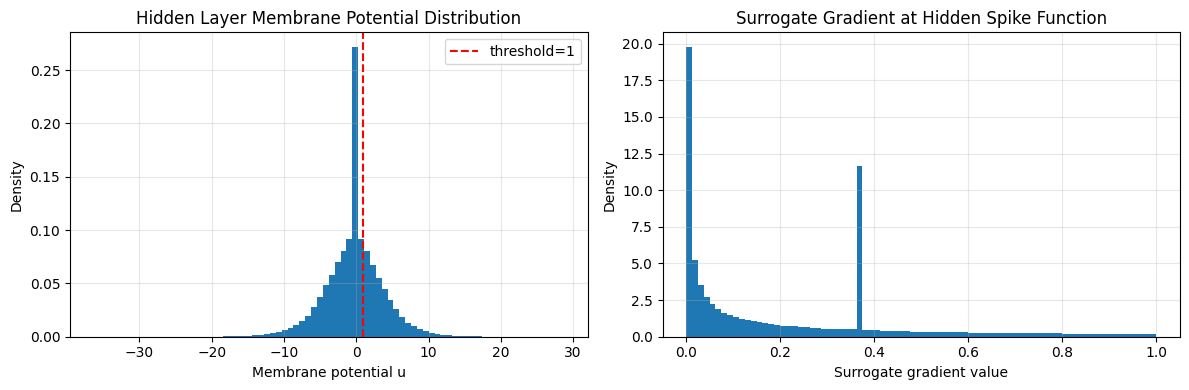

Saved to log/debug_tau_surrogate.png


In [20]:
net_mp = ISINetwork(NUM_NEURONS, NUM_CLASSES, HIDDEN_UNITS).to(device)

membrane_potentials = []

def _hook_fc1(module, input, output):
    """Capture fc1 output (membrane potential before hidden spike function)."""
    membrane_potentials.append(output.detach().cpu())

handle = net_mp.fc1.register_forward_hook(_hook_fc1)

with torch.no_grad():
    _ = net_mp(x_fixed)

handle.remove()

mp = membrane_potentials[0].numpy()
mp_flat = mp.ravel()

theta = LIF_PARAMS["theta"]
tauRho = LIF_PARAMS["tauRho"]
scaleRho = LIF_PARAMS["scaleRho"]
surrogate_vals = scaleRho / tauRho * np.exp(-np.abs(mp_flat - theta) / tauRho)

print("Hidden membrane potential stats (across batch x neurons x time):")
print(f"  min={mp_flat.min():.4f}  max={mp_flat.max():.4f}")
print(f"  mean={mp_flat.mean():.4f}  std={mp_flat.std():.4f}")
frac_near = float((np.abs(mp_flat - theta) < tauRho).mean())
print(f"  fraction within 1 tauRho of threshold: {frac_near:.3%}")
print()
print("Surrogate gradient stats (scaleRho/tauRho * exp(-|u-theta|/tauRho)):")
print(f"  mean={surrogate_vals.mean():.6f}  max={surrogate_vals.max():.6f}")
frac_active = float((surrogate_vals > 0.01).mean())
print(f"  fraction > 0.01: {frac_active:.3%}")
print()
if surrogate_vals.mean() < 1e-4:
    print(">>> Surrogate gradient is near-zero -- signal vanishes before reaching psp_filter.")
    print("    Consider increasing scaleRho or tauRho to widen the surrogate window.")
else:
    print(">>> Surrogate gradient is non-negligible at the hidden layer.")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(mp_flat, bins=80, density=True)
axes[0].axvline(theta, color="red", linestyle="--", label=f"threshold={theta}")
axes[0].set_xlabel("Membrane potential u")
axes[0].set_ylabel("Density")
axes[0].set_title("Hidden Layer Membrane Potential Distribution")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(surrogate_vals, bins=80, density=True)
axes[1].set_xlabel("Surrogate gradient value")
axes[1].set_ylabel("Density")
axes[1].set_title("Surrogate Gradient at Hidden Spike Function")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("log/debug_tau_surrogate.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to log/debug_tau_surrogate.png")

## Summary

| Debug cell | What it tests | Key observation |
|---|---|---|
| **Debug 1** | Filter shape and peak gap | Size of gap a neighbour must close for argmax to shift |
| **Debug 2** | Gradient on `psp_filter.weight` | None/zero --> graph disconnection; small --> bad signal |
| **Debug 3** | Weight delta after 100 steps | No change --> H4; change without peak shift --> H3 |
| **Debug 4** | Argmax step sensitivity | Scale needed on neighbour tap to move tau by one 3 ms step |
| **Debug 5** | CoM tau vs argmax tau over training | CoM moves but argmax flat --> H3; both flat --> H4 |
| **Debug 6** | Surrogate gradient magnitude | Near-zero --> gradient vanishes at spike; explains H2/H4 |

**Likely fix if gradient is negligible (H2/H4):** increase `scaleRho` or
`tauRho` in `LIF_PARAMS` to widen the surrogate window, or initialise
fc1 weights so membrane potentials cluster closer to threshold.

**Likely fix if H3 (weights change but argmax is blind):** use `get_tau_com()`
for monitoring. If tau genuinely needs to move, the filter can be parameterised
directly by a scalar tau rather than learned tap-by-tap.